In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import gtsam
import glob
import open3d as o3d
from tqdm import tqdm

In [2]:
# --- Parameters ---
images_path = "./img/machine_hall/MH_01_easy/mav0/cam0/data/*.png"
distortion_coeffs_path = "./img/machine_hall/MH_01_easy/mav0/cam0/sensor.yaml"
min_features = 2000
N_FRAMES = 100

START_FRAME = 1000      # Initial sequenc frame

fx, fy = 458.654, 457.296
cx, cy = 367.215, 248.375

K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0,  0,  1]], dtype=np.float64)
D = np.array([-0.28340811, 0.07395907, 0.00019359, 1.76187114e-05], dtype=np.float64)

# --- Load and sort images ---

image_files = sorted(glob.glob(images_path))[START_FRAME:START_FRAME + N_FRAMES]

if not image_files:
    raise RuntimeError("No images found in folder!")
print(f"Images loaded: {len(image_files)}")

# --- Initialize FAST detector ---
fast = cv2.FastFeatureDetector_create(threshold=25, nonmaxSuppression=True)

Images loaded: 100


In [3]:
tracked_points = {}  # {id: (x,y)}

# --- Helper: detect new features and assign IDs ---
def detect_new_features(img, existing_ids):
    global next_feature_id
    keypoints = fast.detect(img, None)
    new_pts = []
    new_ids = []
    for kp in keypoints:
        x, y = kp.pt
        new_pts.append([x, y])
        new_ids.append(next_feature_id)
        tracked_points[next_feature_id] = (x, y)
        next_feature_id += 1
    return np.array(new_pts, dtype=np.float32).reshape(-1, 1, 2), new_ids

In [4]:
# --- Tracking state ---
next_feature_id = 0  # unique ID counter
tracks_per_frame = []  # list of dicts: [{id: (x,y)}, ...]

def load_gray_undistorted(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return cv2.undistort(img, K, D)

# --- First frame ---
prev_img = load_gray_undistorted(image_files[0])
prev_pts, prev_ids = detect_new_features(prev_img, set())
tracks_per_frame.append({pid: tuple(pt.ravel()) for pid, pt in zip(prev_ids, prev_pts)})

# --- Process frames ---
for fname in tqdm(image_files[1:N_FRAMES]):
    frame = load_gray_undistorted(fname)

    # Track previous points with optical flow
    next_pts, status, _ = cv2.calcOpticalFlowPyrLK(prev_img, frame, prev_pts, None)
    status = status.flatten()

    # Keep only successfully tracked points
    good_new = next_pts[status == 1]
    good_old = prev_pts[status == 1]
    good_ids = [pid for pid, st in zip(prev_ids, status) if st == 1]

    # Update positions
    for pid, pt in zip(good_ids, good_new):
        tracked_points[pid] = pt

    # If features drop below threshold, add new ones
    if  len(good_new) < min_features:
        new_pts, new_ids = detect_new_features(frame, set(good_ids))
        good_new = np.vstack([good_new.reshape(-1, 1, 2), new_pts])
        good_ids.extend(new_ids)

    # Store current frame's tracks
    tracks_per_frame.append({pid: pt.ravel() for pid, pt in zip(good_ids, good_new)})

    # Update for next frame
    prev_img = frame
    prev_pts = good_new.reshape(-1, 1, 2)
    prev_ids = good_ids

print("Feature per frame:", [len(t) for t in tracks_per_frame[:5]])


100%|██████████| 99/99 [00:01<00:00, 94.17it/s]

Feature per frame: [1473, 2877, 2839, 2795, 2751]


In [5]:
def compute_essential(tracks_per_frame, i, j, K):
    # Get correspondences by ID
    ids_i = set(tracks_per_frame[i].keys())
    ids_j = set(tracks_per_frame[j].keys())
    common_ids = list(ids_i & ids_j)  # intersection

    if len(common_ids) < 5:
        raise ValueError("Not enough matches to compute Essential matrix")

    pts1 = np.array([tracks_per_frame[i][pid] for pid in common_ids], dtype=np.float32)
    pts2 = np.array([tracks_per_frame[j][pid] for pid in common_ids], dtype=np.float32)

    # Compute essential matrix
    E, inliers = cv2.findEssentialMat(pts1, pts2, K, method=cv2.RANSAC, prob=0.999, threshold=1.0)

    return E, inliers, pts1, pts2, np.array(common_ids)

In [6]:
# --- Adaptive bootstrap: cerca automaticamente la miglior coppia (0, k) ---
MAX_BOOTSTRAP_GAP = 60     # massimo k da provare (3s a 20Hz su EuRoC)
MIN_BOOT_INLIERS  = 100    # inlier minimi da recoverPose
MIN_PIX_DISP      = 5.0    # spostamento medio feature in pixel (serve moto rilevabile)
# Nota: cv2.recoverPose normalizza SEMPRE t a lunghezza 1 (ambiguita' di scala monoculare),
# quindi un check su ||t|| non serve a niente. La degenerazione di E si rileva dagli inlier.

def try_bootstrap(tracks_per_frame, k, K):
    try:
        E, inl_E, pts1, pts2, common_ids = compute_essential(tracks_per_frame, 0, k, K)
    except Exception:
        return None
    if E is None:
        return None
    pts1 = np.asarray(pts1, dtype=np.float64).reshape(-1, 2)
    pts2 = np.asarray(pts2, dtype=np.float64).reshape(-1, 2)
    if len(pts1) < MIN_BOOT_INLIERS:
        return None
    n_inl, R, t, mask = cv2.recoverPose(E, pts1, pts2, K)
    disp = float(np.linalg.norm(pts2 - pts1, axis=1).mean())
    return (n_inl, R, t, mask, pts1, pts2, common_ids, disp)

k_boot = None
print("Ricerca coppia di bootstrap (0, k):")
max_k = min(MAX_BOOTSTRAP_GAP, N_FRAMES - 1)
for k in range(1, max_k + 1):
    out = try_bootstrap(tracks_per_frame, k, K)
    if out is None:
        continue
    n_inl, R, t, mask, pts1_k, pts2_k, common_ids_k, disp = out
    ok = (n_inl >= MIN_BOOT_INLIERS and disp >= MIN_PIX_DISP)
    # Stampo solo ogni 5 tentativi (o quando OK) per non inondare il log
    if ok or k % 5 == 0 or k == 1:
        print(f"  (0,{k:2d}) inl={n_inl:4d}, disp={disp:5.2f}px  -> {'OK' if ok else 'scart'}")
    if ok:
        k_boot = k
        R1, t1 = R, t
        pts1, pts2, common_ids, mask = pts1_k, pts2_k, common_ids_k, mask
        break

if k_boot is None:
    # Diagnostico: mostra il profilo di movimento per capire cosa succede
    print("\n--- Diagnostico: profilo di movimento sulla sequenza ---")
    for k in [10, 20, 40, 60, min(80, N_FRAMES-1)]:
        if k >= N_FRAMES:
            continue
        common = set(tracks_per_frame[0]) & set(tracks_per_frame[k])
        if len(common) < 10:
            print(f"  frame 0 <-> {k:3d}: solo {len(common)} feature comuni")
            continue
        disp = float(np.mean([
            np.linalg.norm(np.asarray(tracks_per_frame[k][pid]) - np.asarray(tracks_per_frame[0][pid]))
            for pid in common
        ]))
        print(f"  frame 0 <-> {k:3d}: {len(common):4d} feature comuni, disp media {disp:.2f}px")
    raise RuntimeError(
        f"Nessuna coppia di bootstrap valida trovata tra (0,1)..(0,{MAX_BOOTSTRAP_GAP}). "
        f"Il profilo qui sopra suggerisce che la camera e' ferma: cambia START_FRAME "
        f"per spostarti in una regione con movimento."
    )

print(f"\nBootstrap scelto: frame 0 <-> frame {k_boot}")
print(f"c{k_boot}_R_w:\n{R1}")
print(f"c{k_boot}_t_w:\n{t1}")


Ricerca coppia di bootstrap (0, k):
  (0, 1) inl= 114, disp=15.00px  -> OK

Bootstrap scelto: frame 0 <-> frame 1
c1_R_w:
[[ 0.99976661  0.00564888 -0.02085238]
 [-0.00572804  0.99997661 -0.00373861]
 [ 0.02083078  0.00385718  0.99977558]]
c1_t_w:
[[-0.57544218]
 [-0.33422911]
 [-0.74642963]]


In [7]:
# Projection matrices
P1 = K @ np.hstack([np.eye(3), np.zeros((3, 1))])
P2 = K @ np.hstack([R1, t1])

# Select only inlier correspondences
inlier_mask = mask.ravel().astype(bool)
pts1_inl = pts1[inlier_mask]
pts2_inl = pts2[inlier_mask]
common_ids_inl = common_ids[inlier_mask]
print(f"Inliers: {len(common_ids_inl)}")

# Triangulate
points_h = cv2.triangulatePoints(P1, P2, pts1_inl.T, pts2_inl.T)

# Convert from homogeneous to 3D
points_3d_ids = common_ids_inl
points_3d = (points_h[:3] / points_h[3]).T

print(f"Inliers E: {len(common_ids_inl)}")
overlap = set(points_3d_ids) & set(tracks_per_frame[2].keys())
print(f"ID triangolati presenti anche in frame 2: {len(overlap)}")

good = (
    ~np.isnan(points_3d).any(axis=1) &
    ~np.isinf(points_3d).any(axis=1) &
    (points_3d[:, 2] > 0) &
    (np.linalg.norm(points_3d, axis=1) < 100)
)
points_3d = points_3d[good]
points_3d_ids = points_3d_ids[good]

Inliers: 114
Inliers E: 114
ID triangolati presenti anche in frame 2: 112


In [8]:
def register_frame_pnp(tracks_per_frame, frame_idx, points_3d, point_ids, K):
    # Build 3D-2D correspondences
    pts3d = []
    pts2d = []
    for pid, X in zip(point_ids, points_3d):
        if pid in tracks_per_frame[frame_idx]:
            pts3d.append(X)
            pts2d.append(tracks_per_frame[frame_idx][pid])
    if len(pts3d) < 6:
        raise ValueError(f"Frame {frame_idx}: not enough 2D-3D matches for PnP")

    pts3d = np.array(pts3d, dtype=np.float64)
    pts2d = np.array(pts2d, dtype=np.float64)

    # Solve PnP with RANSAC
    success, rvec, tvec, inliers = cv2.solvePnPRansac(
        pts3d, pts2d, K, distCoeffs=None,
        flags=cv2.SOLVEPNP_ITERATIVE
    )
    if not success:
        raise RuntimeError(f"PnP failed for frame {frame_idx}")

    # Convert to rotation matrix
    R, _ = cv2.Rodrigues(rvec)
    t = tvec.ravel()

    return R, t, inliers

In [9]:
# --- Unified loop: PnP + re-triangulation ---
RETRIANGULATE_THRESHOLD = 150   # se gli inlier PnP scendono sotto, ritriangola
REF_GAP = 5                     # quanti frame indietro guardare per il ref di triangolazione
MIN_BASELINE = 0.05             # baseline minima ref<->curr per triangolare

# Stato globale: mappa id -> 3D, e pose per ogni frame (R, t mondo->camera)
points_3d_map = {int(pid): X.astype(np.float64) for pid, X in zip(points_3d_ids, points_3d)}
pose_per_frame = {
    0: (np.eye(3), np.zeros(3)),
    k_boot: (R1.copy(), t1.ravel().copy()),
}

def proj_matrix(R, t, K):
    t = np.asarray(t).reshape(3, 1)
    return K @ np.hstack([R, t])

# --- Riempio le pose dei frame intermedi 1..k_boot-1 via PnP sui punti del bootstrap ---
# (LK garantisce che i punti triangolati tra 0 e k_boot siano visibili anche nei frame intermedi)
for idx in range(1, k_boot):
    cur = tracks_per_frame[idx]
    pts3d_list, pts2d_list = [], []
    for pid, X in points_3d_map.items():
        if pid in cur:
            pts3d_list.append(X)
            pts2d_list.append(cur[pid])
    if len(pts3d_list) < 6:
        raise RuntimeError(
            f"Frame intermedio {idx}: solo {len(pts3d_list)} match PnP - i punti bootstrap "
            f"non sono sopravvissuti dal frame 0 al frame {idx}"
        )
    pts3d_np = np.asarray(pts3d_list, dtype=np.float64)
    pts2d_np = np.asarray(pts2d_list, dtype=np.float64)
    ok, rvec, tvec, _ = cv2.solvePnPRansac(
        pts3d_np, pts2d_np, K, distCoeffs=None, flags=cv2.SOLVEPNP_ITERATIVE
    )
    if not ok:
        raise RuntimeError(f"PnP fallito su frame intermedio {idx}")
    R_i, _ = cv2.Rodrigues(rvec)
    pose_per_frame[idx] = (R_i, tvec.ravel())

if k_boot > 1:
    print(f"Pose intermedie riempite via PnP: frame 1..{k_boot - 1}")

# --- Loop principale: PnP + eventuale re-triangolazione ---
for idx in tqdm(range(k_boot + 1, N_FRAMES)):
    cur_tracks = tracks_per_frame[idx]

    # --- Raccolgo corrispondenze 2D-3D con la mappa corrente ---
    pts3d_list, pts2d_list = [], []
    for pid, X in points_3d_map.items():
        if pid in cur_tracks:
            pts3d_list.append(X)
            pts2d_list.append(cur_tracks[pid])

    if len(pts3d_list) < 6:
        raise ValueError(
            f"Frame {idx}: solo {len(pts3d_list)} match 2D-3D - la mappa si e' svuotata "
            f"prima che la re-triangolazione potesse rifornirla"
        )

    pts3d_np = np.asarray(pts3d_list, dtype=np.float64)
    pts2d_np = np.asarray(pts2d_list, dtype=np.float64)

    success, rvec, tvec, inliers = cv2.solvePnPRansac(
        pts3d_np, pts2d_np, K, distCoeffs=None, flags=cv2.SOLVEPNP_ITERATIVE
    )
    if not success:
        raise RuntimeError(f"PnP failed for frame {idx}")

    R, _ = cv2.Rodrigues(rvec)
    t = tvec.ravel()
    pose_per_frame[idx] = (R, t)
    n_inliers = 0 if inliers is None else len(inliers)

    # --- Re-triangolazione se gli inlier sono pochi ---
    n_added = 0
    if n_inliers < RETRIANGULATE_THRESHOLD:
        k_ref = max(0, idx - REF_GAP)
        R_ref, t_ref = pose_per_frame[k_ref]
        baseline = float(np.linalg.norm(np.asarray(t) - np.asarray(t_ref)))

        if baseline >= MIN_BASELINE:
            ref_tracks = tracks_per_frame[k_ref]
            new_ids = [pid for pid in cur_tracks.keys()
                       if pid in ref_tracks and pid not in points_3d_map]

            if len(new_ids) >= 10:
                pts_ref = np.asarray([ref_tracks[pid] for pid in new_ids], dtype=np.float64).T
                pts_cur = np.asarray([cur_tracks[pid] for pid in new_ids], dtype=np.float64).T

                P_ref = proj_matrix(R_ref, t_ref, K)
                P_cur = proj_matrix(R, t, K)

                pts_h = cv2.triangulatePoints(P_ref, P_cur, pts_ref, pts_cur)
                X_world = (pts_h[:3] / pts_h[3]).T   # coords nel frame 0 = world

                X_ref_c = (R_ref @ X_world.T + np.asarray(t_ref).reshape(3, 1)).T
                X_cur_c = (R @ X_world.T + t.reshape(3, 1)).T
                good = (
                    ~np.isnan(X_world).any(axis=1) &
                    ~np.isinf(X_world).any(axis=1) &
                    (X_ref_c[:, 2] > 0) & (X_cur_c[:, 2] > 0) &
                    (np.linalg.norm(X_world, axis=1) < 100)
                )
                for pid, X, ok_mask in zip(new_ids, X_world, good):
                    if ok_mask:
                        points_3d_map[int(pid)] = X
                        n_added += 1

    if idx % 10 == 0 or n_added > 0 or n_inliers < RETRIANGULATE_THRESHOLD:
        print(f"Frame {idx:3d}: inliers={n_inliers:4d}, |map|={len(points_3d_map):5d}, +{n_added} nuovi")

# --- Ricostruisco gli array compatibili con la BA (cella 9) ---
points_3d_ids = np.array(sorted(points_3d_map.keys()), dtype=np.int64)
points_3d = np.array([points_3d_map[int(pid)] for pid in points_3d_ids], dtype=np.float64)

initial_poses = []
for k in range(N_FRAMES):
    R, t = pose_per_frame[k]
    initial_poses.append((R, np.asarray(t).reshape(3, 1)))

print(f"\nTotale: {len(points_3d_ids)} landmark, {len(initial_poses)} pose")


 24%|██▍       | 24/98 [00:00<00:00, 238.70it/s]

Frame   2: inliers= 110, |map|=  285, +171 nuovi
Frame   8: inliers= 115, |map|= 1742, +1457 nuovi
Frame  10: inliers=1280, |map|= 1742, +0 nuovi
Frame  20: inliers= 632, |map|= 1742, +0 nuovi
Frame  30: inliers= 489, |map|= 1742, +0 nuovi
Frame  40: inliers= 462, |map|= 1742, +0 nuovi


 73%|███████▎  | 72/98 [00:00<00:00, 230.62it/s]

Frame  50: inliers= 356, |map|= 1742, +0 nuovi
Frame  60: inliers= 423, |map|= 1742, +0 nuovi
Frame  70: inliers= 334, |map|= 1742, +0 nuovi
Frame  80: inliers= 312, |map|= 1742, +0 nuovi


 99%|█████████▉| 97/98 [00:00<00:00, 236.58it/s]

Frame  90: inliers= 274, |map|= 1742, +0 nuovi


100%|██████████| 98/98 [00:00<00:00, 234.04it/s]


Totale: 1742 landmark, 100 pose


In [10]:
graph = gtsam.NonlinearFactorGraph()
initial_values = gtsam.Values()
cal = gtsam.Cal3_S2(fx, fy, 0, cx, cy)

base_noise = gtsam.noiseModel.Isotropic.Sigma(2, 1.0)
cauchy_mest = gtsam.noiseModel.mEstimator.Cauchy(1.0)
robust_noise = gtsam.noiseModel.Robust.Create(cauchy_mest, base_noise)

camera_ids = []
for idx, pose in enumerate(initial_poses):
    cam_sym = gtsam.symbol('c', int(idx))
    cam_pose = gtsam.Pose3(gtsam.Rot3(pose[0]), pose[1]).inverse()
    initial_values.insert(cam_sym, cam_pose)
    camera_ids.append(cam_sym)

pose_prior_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([1e-6]*6))
cam_sym = gtsam.symbol('c', 0)
graph.add(gtsam.PriorFactorPose3(cam_sym, gtsam.Pose3(), pose_prior_noise))

points_ids = []
for point_idx, point in zip(points_3d_ids, points_3d):
  # Check if 3d points is seen in at least 3 images
  observations = [(img_idx, pts[point_idx]) for img_idx, pts in enumerate(tracks_per_frame) if point_idx in pts]
  if len(observations) < 3:
    continue

  # Add point symbol
  point_sym = gtsam.symbol('p', int(point_idx))
  initial_values.insert(point_sym, gtsam.Point3(float(point[0]), float(point[1]), float(point[2])))
  points_ids.append(point_sym)

  # Add reprojection factors
  for img_idx, point_2d in observations:
    measured = gtsam.Point2(float(point_2d[0]), float(point_2d[1]))
    cam_sym = gtsam.symbol('c', int(img_idx))
    proj_factor = gtsam.GenericProjectionFactorCal3_S2(measured, robust_noise, cam_sym, point_sym, cal)
    graph.add(proj_factor)

print(f"Total points inserted {len(points_ids)}")

Total points inserted 1740


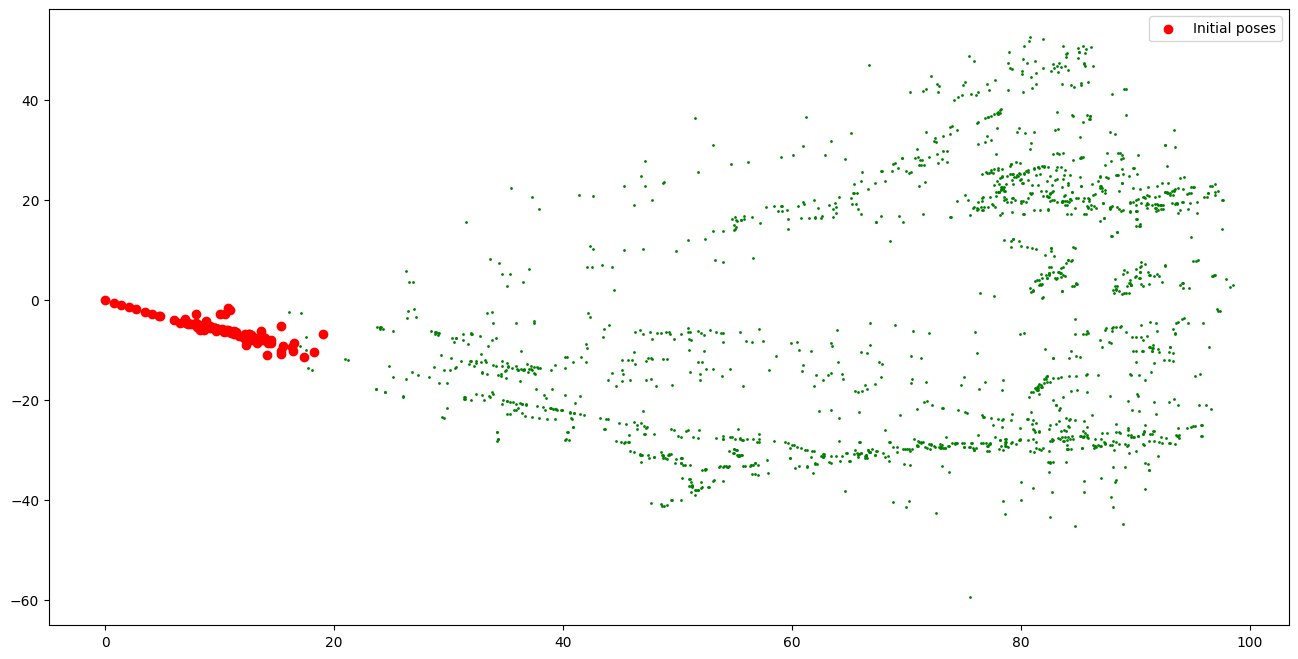

In [11]:
initial_poses = []
final_poses = []
for cam_sym in camera_ids:
  pose_initial = initial_values.atPose3(cam_sym)
  initial_poses.append((pose_initial.translation()[2], -pose_initial.translation()[0]))
initial_poses = np.array(initial_poses)

points = []
for point_sym in points_ids:
    point = initial_values.atPoint3(point_sym)
    points.append((point[2], -point[0]))
points = np.array(points)

plt.figure(figsize=(16,8))
plt.scatter(points[:, 0], points[:, 1], c='green', s=1)
plt.scatter(initial_poses[:, 0], initial_poses[:, 1], c='red', label='Initial poses')
plt.legend()

In [12]:
# Optimize
params = gtsam.LevenbergMarquardtParams()
params.setVerbosity("TERMINATION")   # "SILENT", "SUMMARY", "TERMINATION"
params.setVerbosityLM("TERMINATION")   # "SILENT", "SUMMARY", "TERMINATION"
params.setMaxIterations(100)
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial_values, params)
result = optimizer.optimize()
optimizer.print()

converged
errorThreshold: LevenbergMarquardtOptimizer
45032 <? 0
absoluteDecrease: 0.427100613459 <? 1e-05
relativeDecrease: 9.48429737143e-06 <? 1e-05
iterations: 49 >? 100
  parameters:

relative decrease threshold: 1e-05
absolute decrease threshold: 1e-05
      total error threshold: 0
         maximum iterations: 100
                  verbosity: TERMINATION
         linear solver type: MULTIFRONTAL CHOLESKY
                   ordering: COLAMD
              lambdaInitial: 1e-05
               lambdaFactor: 10
           lambdaUpperBound: 100000
           lambdaLowerBound: 0
           minModelFidelity: 0.001
            diagonalDamping: 0
                minDiagonal: 1e-06
                maxDiagonal: 1e+32
                verbosityLM: TERMINATION


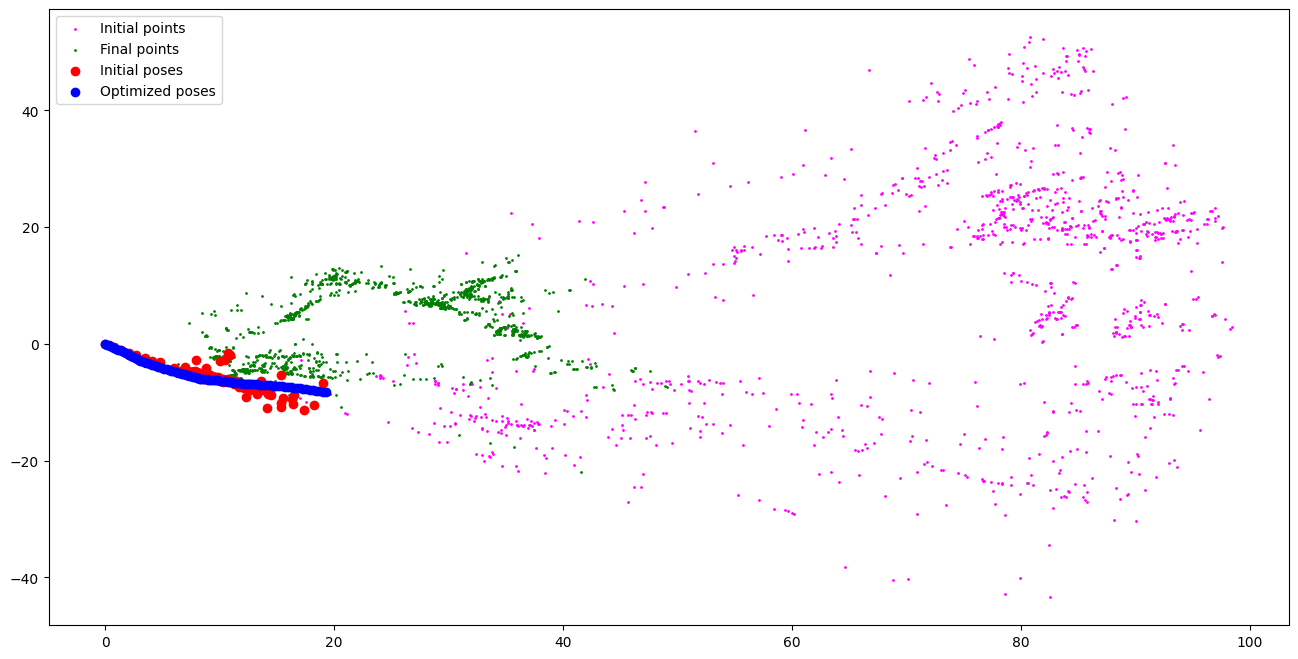

In [13]:
# Keep same scale factor of initial poses
scale = np.linalg.norm(initial_values.atPose3(camera_ids[-1]).translation()) / np.linalg.norm(result.atPose3(camera_ids[-1]).translation())

initial_poses = []
final_poses = []
for cam_sym in camera_ids:
  pose_initial = initial_values.atPose3(cam_sym)
  initial_poses.append((pose_initial.translation()[2], -pose_initial.translation()[0]))

  pose_final = result.atPose3(cam_sym)
  final_poses.append((scale*pose_final.translation()[2], -scale*pose_final.translation()[0]))

initial_poses = np.array(initial_poses)
final_poses = np.array(final_poses)


initial_points = []
points = []
for point_sym in points_ids:
    point_initial = initial_values.atPoint3(point_sym)
    point_final = result.atPoint3(point_sym)
    if np.linalg.norm(point_final) > 50/scale or point_final[2] < 0:
      continue
    initial_points.append((point_initial[2], -point_initial[0]))
    points.append((scale*point_final[2], -scale*point_final[0]))
initial_points = np.array(initial_points)
points = np.array(points)

plt.figure(figsize=(16,8))
plt.scatter(initial_points[:, 0], initial_points[:, 1], c='magenta', s=1, label='Initial points')
plt.scatter(points[:, 0], points[:, 1], c='green', s=1, label='Final points')
plt.scatter(initial_poses[:, 0], initial_poses[:, 1], c='red', label='Initial poses')
plt.scatter(final_poses[:, 0], final_poses[:, 1], c='blue', label='Optimized poses')
plt.legend()


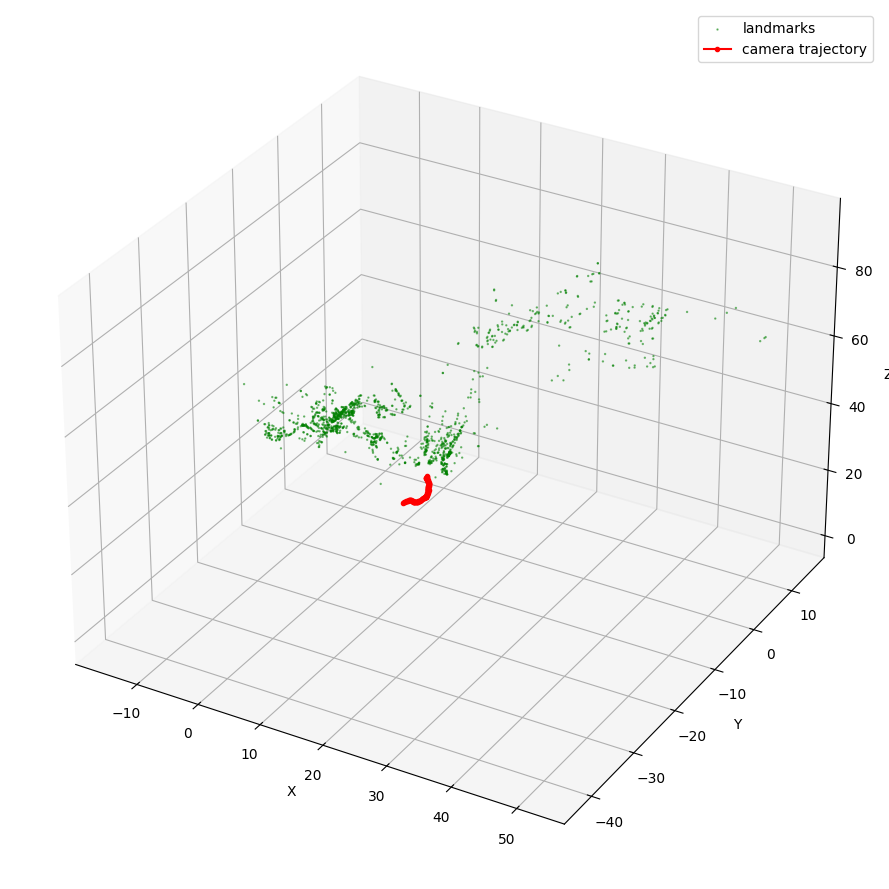

In [14]:
# --- Salva il risultato e visualizza inline con matplotlib ---
# (Open3D Visualizer su macOS+Jupyter crasha il kernel alla chiusura;
#  salviamo .ply per viewer esterno e plottiamo inline)
pts = []
for key in result.keys():
    if chr(gtsam.Symbol(key).chr()) == "p":
        pt = result.atPoint3(key)
        if np.linalg.norm(pt) <= 100/scale and pt[2] > 0:
            pts.append([pt[0]*scale, pt[1]*scale, pt[2]*scale])
pts_np = np.array(pts)

cam_xyz = []
for key in result.keys():
    if chr(gtsam.Symbol(key).chr()) == "c":
        t = result.atPose3(key).translation() * scale
        cam_xyz.append([t[0], t[1], t[2]])
cam_xyz = np.array(cam_xyz)

# Plot inline 3D
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(pts_np[:,0], pts_np[:,1], pts_np[:,2], c="green", s=0.5, alpha=0.5, label="landmarks")
ax.plot(cam_xyz[:,0], cam_xyz[:,1], cam_xyz[:,2], "r-o", markersize=3, label="camera trajectory")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.legend()
plt.tight_layout()
plt.show()


In [15]:
# --- Open3D interactive viewer (opzionale, attenzione: crasha il kernel alla chiusura con q) ---
def gtsam_result_to_open3d(result, pose_keys_prefix="c", point_keys_prefix="p"):
    geometries = []
    pts = []
    for key in result.keys():
        ch = chr(gtsam.Symbol(key).chr())
        if ch == point_keys_prefix:
            pt = result.atPoint3(key)
            if np.linalg.norm(pt) > 100/scale or pt[2] < 0:
                continue
            pts.append([pt[0]*scale, pt[1]*scale, pt[2]*scale])
    if pts:
        pts_np = np.array(pts)
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts_np)
        pcd.paint_uniform_color([0.1, 0.7, 0.1])
        geometries.append(pcd)
    for key in result.keys():
        ch = chr(gtsam.Symbol(key).chr())
        if ch == pose_keys_prefix:
            pose = result.atPose3(key)
            T = pose.matrix()
            T[0:3, 3] *= scale
            frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.5)
            frame.transform(T)
            geometries.append(frame)
    return geometries

geometries = gtsam_result_to_open3d(result)
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="BA result", width=1280, height=720)
for g in geometries:
    vis.add_geometry(g)
try:
    vis.run()
finally:
    vis.destroy_window()
    del vis
